<a href="https://colab.research.google.com/github/janani26121992/AI-Projects/blob/main/Credit_Card_Default_Model_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Credit Card Default Model prediciton using Artificial Neural Network - ANN


Build a model that will predict borrowers’ chance of defaulting on credit loans.

Data Gathering is done from UCI website. For that install ucimlrepo first.

In [2]:
pip install ucimlrepo

In [8]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
default_of_credit_card_clients = fetch_ucirepo(id=350)

# data (as pandas dataframes)
X = default_of_credit_card_clients.data.features
y = default_of_credit_card_clients.data.targets



In [9]:
X.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [10]:
new_cols = ['Credit_Amount','Gender','Education','Marital status','Age','Repay_Sept','Repay_Aug','Repay_July','Repay_June','Repay_May','Repay_April',
            'Bill_Sept','Bill_Aug','Bill_July','Bill__June','Bill_May','Bill_April',
           'Amount_paid_Sept','Amount_paid_Aug','Amount_paid_July','Amount_paid_June','Amount_paid_May','Amount_paid']


In [12]:
X.columns=new_cols
X.head()

,Credit_Amount,Gender,Education,Marital status,Age,Repay_Sept,Repay_Aug,Repay_July,Repay_June,Repay_May,...,Bill_July,Bill__June,Bill_May,Bill_April,Amount_paid_Sept,Amount_paid_Aug,Amount_paid_July,Amount_paid_June,Amount_paid_May,Amount_paid
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [13]:
y.value_counts()

,count
Y,
0,23364
1,6636


In [14]:
((y.value_counts())/len(y))*100

,count
Y,
0,77.88
1,22.12


<Axes: xlabel='Y'>

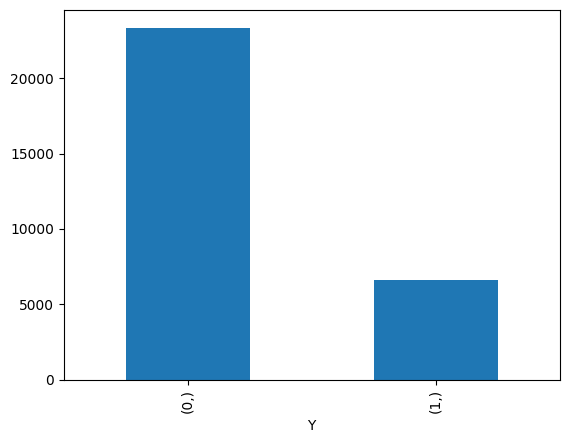

In [15]:
y.value_counts().plot(kind='bar')

This dataset has imbalanced data for target features

In [16]:
X.dtypes

,0
Credit_Amount,int64
Gender,int64
Education,int64
Marital status,int64
Age,int64
Repay_Sept,int64
Repay_Aug,int64
Repay_July,int64
Repay_June,int64
Repay_May,int64


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
num_pipe=make_pipeline(SimpleImputer(strategy='mean'),
                       StandardScaler()
                       ).set_output(transform='pandas')



In [20]:
x_pre=num_pipe.fit_transform(X)
x_pre

,Credit_Amount,Gender,Education,Marital status,Age,Repay_Sept,Repay_Aug,Repay_July,Repay_June,Repay_May,...,Bill_July,Bill__June,Bill_May,Bill_April,Amount_paid_Sept,Amount_paid_Aug,Amount_paid_July,Amount_paid_June,Amount_paid_May,Amount_paid
0,-1.136720,0.810161,0.185828,-1.057295,-1.246020,1.794564,1.782348,-0.696663,-0.666599,-1.530046,...,-0.667993,-0.672497,-0.663059,-0.652724,-0.341942,-0.227086,-0.296801,-0.308063,-0.314136,-0.293382
1,-0.365981,0.810161,0.185828,0.858557,-1.029047,-0.874991,1.782348,0.138865,0.188746,0.234917,...,-0.639254,-0.621636,-0.606229,-0.597966,-0.341942,-0.213588,-0.240005,-0.244230,-0.314136,-0.180878
2,-0.597202,0.810161,0.185828,0.858557,-0.161156,0.014861,0.111736,0.138865,0.188746,0.234917,...,-0.482408,-0.449730,-0.417188,-0.391630,-0.250292,-0.191887,-0.240005,-0.244230,-0.248683,-0.012122
3,-0.905498,0.810161,0.185828,-1.057295,0.164303,0.014861,0.111736,0.138865,0.188746,0.234917,...,0.032846,-0.232373,-0.186729,-0.156579,-0.221191,-0.169361,-0.228645,-0.237846,-0.244166,-0.237130
4,-0.905498,-1.234323,0.185828,-1.057295,2.334029,-0.874991,0.111736,-0.696663,0.188746,0.234917,...,-0.161189,-0.346997,-0.348137,-0.331482,-0.221191,1.335034,0.271165,0.266434,-0.269039,-0.255187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,0.404759,-1.234323,1.451114,-1.057295,0.381275,0.014861,0.111736,0.138865,0.188746,0.234917,...,2.326690,0.695474,-0.149259,-0.384392,0.171250,0.611048,-0.012648,-0.113564,0.013131,-0.237130
29996,-0.134759,-1.234323,1.451114,0.858557,0.815221,-0.874991,-0.723570,-0.696663,-0.666599,0.234917,...,-0.627430,-0.532924,-0.577691,-0.652724,-0.231032,-0.103955,0.214255,-0.299828,-0.314136,-0.293382
29997,-1.059646,-1.234323,0.185828,0.858557,0.164303,3.574267,2.617654,1.809921,-0.666599,0.234917,...,-0.638158,-0.347961,-0.324517,-0.327687,-0.341942,-0.256990,0.952725,-0.039964,-0.183229,-0.119001
29998,-0.674276,-1.234323,1.451114,-1.057295,0.598248,0.904712,-0.723570,0.138865,0.188746,0.234917,...,0.422373,0.147844,-0.468063,0.169130,4.844316,-0.109033,-0.229895,-0.185120,3.152536,-0.191904


In [28]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x_pre,y,train_size=0.7,random_state=21)

Balance the Y samples using SMOTE technique

In [22]:
pip install imblearn

In [29]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()
x_sampl,y_sampl = smote.fit_resample(xtrain,ytrain)

In [30]:
y_sampl.value_counts()

,count
Y,
0,16364
1,16364


In [32]:
xtrain.shape

(21000, 23)

In [31]:
xtrain.shape[1]

23

Build Neural Network model

In [37]:
from keras.models import Sequential
from keras.layers import Input,Dense


# Intialize the model
model = Sequential()

# Add the Input layer
model.add(Input(shape=(xtrain.shape[1],)))

# Add the Hidden layer1
model.add(Dense(units=64,activation='relu'))


# Add the Output layer
model.add(Dense(units=1,activation='sigmoid'))

In [38]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [39]:
nn = model.fit(x_sampl,y_sampl,validation_split=0.2,epochs=50)

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6911 - loss: 0.6072 - val_accuracy: 0.4905 - val_loss: 0.7437
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7429 - loss: 0.5453 - val_accuracy: 0.4772 - val_loss: 0.7972
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7476 - loss: 0.5351 - val_accuracy: 0.4899 - val_loss: 0.7870
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7468 - loss: 0.5354 - val_accuracy: 0.4539 - val_loss: 0.8492
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7441 - loss: 0.5353 - val_accuracy: 0.5038 - val_loss: 0.7722
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7484 - loss: 0.5299 - val_accuracy: 0.5124 - val_loss: 0.7845
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7475 - loss: 0.5307 - val_accuracy: 0.4817 - val_loss: 0.8408
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7490 - loss: 0.5261 - val_accuracy: 0.

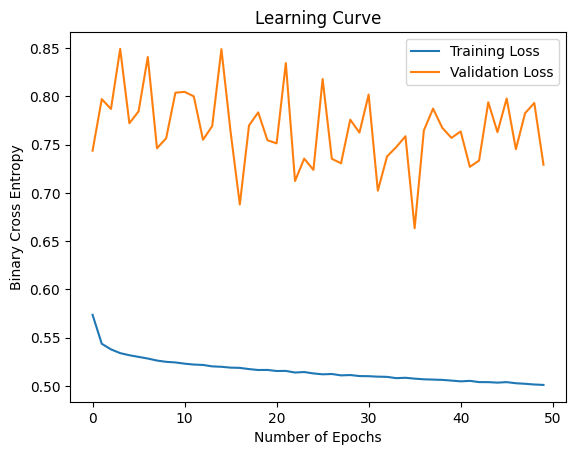

In [40]:
import matplotlib.pyplot as plt
plt.plot(nn.history['loss'],label='Training Loss')
plt.plot(nn.history['val_loss'],label='Validation Loss')
plt.xlabel("Number of Epochs")
plt.ylabel("Binary Cross Entropy")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [41]:

# Intialize the model
model = Sequential()

# Add the Input layer
model.add(Input(shape=(xtrain.shape[1],)))

# Add the Hidden layer1
model.add(Dense(units=64,activation='relu'))

# Add the Hidden layer2
model.add(Dense(units=32,activation='relu'))

# Add the Output layer
model.add(Dense(units=1,activation='sigmoid'))

In [43]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [47]:
nn = model.fit(x_sampl,y_sampl,validation_split=0.2,epochs=100)

Epoch 1/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7947 - loss: 0.4313 - val_accuracy: 0.6555 - val_loss: 0.5910
Epoch 2/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8031 - loss: 0.4239 - val_accuracy: 0.6059 - val_loss: 0.6849
Epoch 3/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7985 - loss: 0.4301 - val_accuracy: 0.5920 - val_loss: 0.7131
Epoch 4/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7985 - loss: 0.4275 - val_accuracy: 0.6515 - val_loss: 0.6124
Epoch 5/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7959 - loss: 0.4325 - val_accuracy: 0.6419 - val_loss: 0.6387
Epoch 6/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8021 - loss: 0.4228 - val_accuracy: 0.6923 - val_loss: 0.5656
Epoch 7/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7970 - loss: 0.4266 - val_accuracy: 0.6800 - val_loss: 0.6100
Epoch 8/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7988 - loss: 0.4266 - val_accu

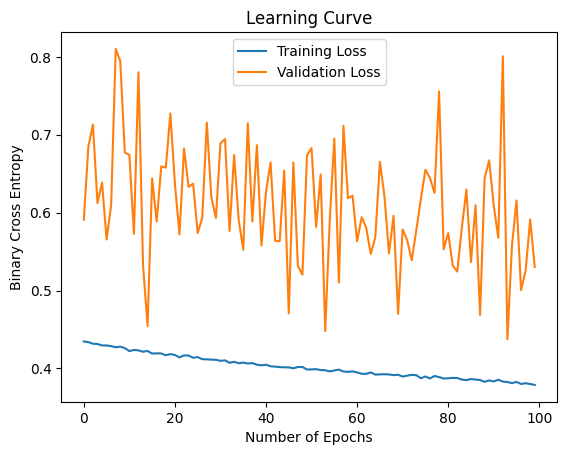

In [48]:
import matplotlib.pyplot as plt
plt.plot(nn.history['loss'],label='Training Loss')
plt.plot(nn.history['val_loss'],label='Validation Loss')
plt.xlabel("Number of Epochs")
plt.ylabel("Binary Cross Entropy")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [50]:
model.evaluate(xtest,ytest)

282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7546 - loss: 0.6628


[0.6705212593078613, 0.7513333559036255]

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay
ypreds = model.predict(xtest)
ypreds[:10]

282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[0.2757631 ],
       [0.42583823],
       [0.13715947],
       [0.00122432],
       [0.01821307],
       [0.37755567],
       [0.66414815],
       [0.0095999 ],
       [0.92070645],
       [0.06859867]], dtype=float32)

In [53]:
ypreds_new=[]
for i in ypreds:
    if i>0.5:
      ypreds_new.append(1)
    else:
      ypreds_new.append(0)
ypreds_new[:10]

[0, 0, 0, 0, 0, 0, 1, 0, 1, 0]

In [55]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
print(classification_report(ytest,ypreds_new))


              precision    recall  f1-score   support

           0       0.85      0.82      0.84      7000
           1       0.45      0.51      0.48      2000

    accuracy                           0.75      9000
   macro avg       0.65      0.67      0.66      9000
weighted avg       0.76      0.75      0.76      9000



In [57]:
ConfusionMatrixDisplay.from_estimator(model,xtest,ytest)

ValueError: ConfusionMatrixDisplay.from_estimator only supports classifiers